In [1]:
import json
import numpy as np



with open("fit_values.json", "r") as f:
    values = json.load(f)
#Siamo riusciti a passare i dati dei fit al file json, ora possiamo usarli per fare i grafici.

#Interpoliamo le norme

masse=[25, 50, 75, 100, 125, 150, 175, 200]
fit_MH_values=values


<function matplotlib.pyplot.show(close=None, block=None)>

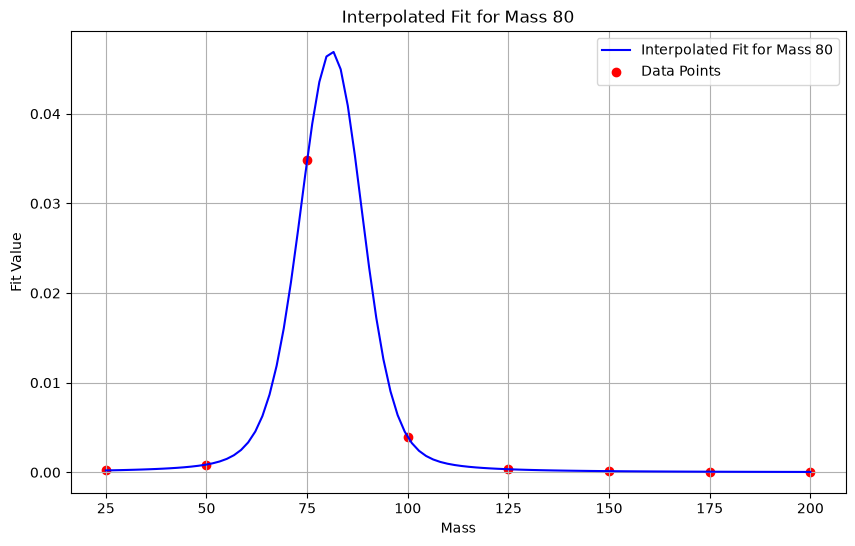

In [2]:
#prendiamo i valori dai file e cerchiamo di creare una  curva interpolata
from Utilities_copy import DoubleVoigtFit, voigt2
import matplotlib.pyplot as plt

DoubleVoigt_MH80=DoubleVoigtFit(80, fit_MH_values)

fit_parameters_80=DoubleVoigt_MH80.get_fit_parameters()

x_80=np.linspace(25, 200, 100)
y_80=voigt2(x_80, fit_parameters_80["norm"], fit_parameters_80["mu"], fit_parameters_80["sigma"], fit_parameters_80["gamma"], fit_parameters_80["norm2"], fit_parameters_80["mu2"], fit_parameters_80["sigma2"], fit_parameters_80["gamma2"])

plt.figure(figsize=(10, 6))
plt.plot(x_80, y_80, label='Interpolated Fit for Mass 80', color='blue')
plt.scatter(masse, [voigt2(m, fit_parameters_80["norm"], fit_parameters_80["mu"], fit_parameters_80["sigma"], fit_parameters_80["gamma"], fit_parameters_80["norm2"], fit_parameters_80["mu2"], fit_parameters_80["sigma2"], fit_parameters_80["gamma2"]) for m in masse], color='red', label='Data Points')
plt.title('Interpolated Fit for Mass 80')
plt.xlabel('Mass')
plt.ylabel('Fit Value')
plt.legend()
plt.grid()  
plt.show


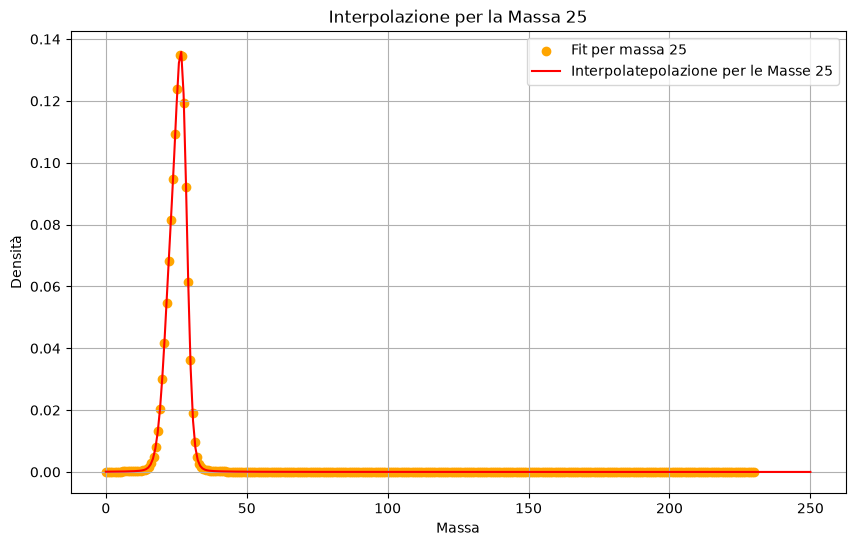

In [3]:
DoubleVoigt_MH25=DoubleVoigtFit(25, fit_MH_values, color='red')


x=np.linspace(0, 230, 300)
y_25=voigt2(x, fit_MH_values["MH25"]["norm"], fit_MH_values["MH25"]["mu"], fit_MH_values["MH25"]["sigma"], fit_MH_values["MH25"]["gamma"], 
         fit_MH_values["MH25"]["norm2"], fit_MH_values["MH25"]["mu2"], fit_MH_values["MH25"]["sigma2"], fit_MH_values["MH25"]["gamma2"])


fig, ax = plt.subplots(figsize=(10, 6))
plt.scatter(x, y_25, label='Fit per massa 25', color='orange')
DoubleVoigt_MH25.grafico(ax=ax)
plt.show()

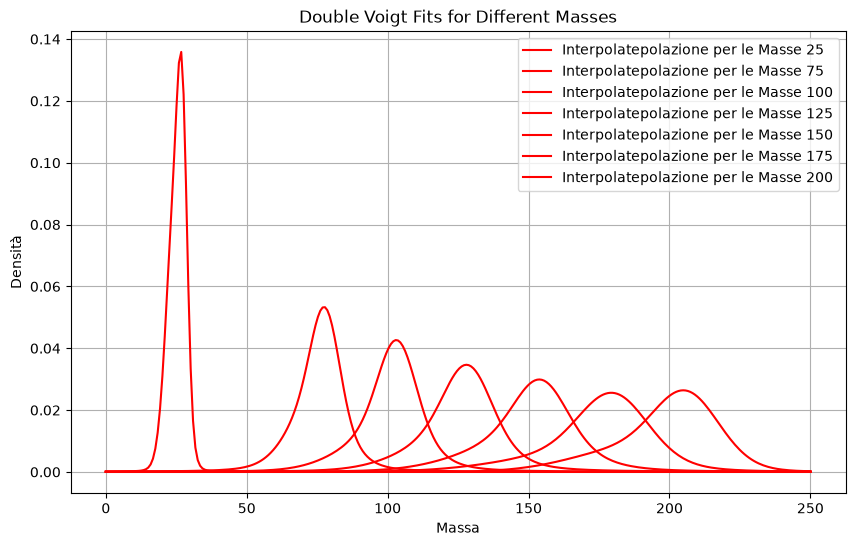

In [4]:
DoubleVoigt_MH50=DoubleVoigtFit(50, fit_MH_values, color='red')
DoubleVoigt_MH75=DoubleVoigtFit(75, fit_MH_values, color='red')
DoubleVoigt_MH100=DoubleVoigtFit(100, fit_MH_values, color='red')
DoubleVoigt_MH125=DoubleVoigtFit(125, fit_MH_values, color='red')
DoubleVoigt_MH150=DoubleVoigtFit(150, fit_MH_values, color='red')
DoubleVoigt_MH175=DoubleVoigtFit(175, fit_MH_values, color='red')
DoubleVoigt_MH200=DoubleVoigtFit(200, fit_MH_values, color='red')

fig, ax = plt.subplots(figsize=(10, 6))
DoubleVoigt_MH25.grafico(ax=ax, color='red')
#DoubleVoigt_MH50.grafico(ax=ax)
DoubleVoigt_MH75.grafico(ax=ax, color='red')
DoubleVoigt_MH100.grafico(ax=ax, color='red')        
DoubleVoigt_MH125.grafico(ax=ax, color='red')
DoubleVoigt_MH150.grafico(ax=ax, color='red')
DoubleVoigt_MH175.grafico(ax=ax, color='red')
DoubleVoigt_MH200.grafico(ax=ax, color='red')
plt.title('Double Voigt Fits for Different Masses')
plt.show()

<Figure size 2000x1200 with 0 Axes>

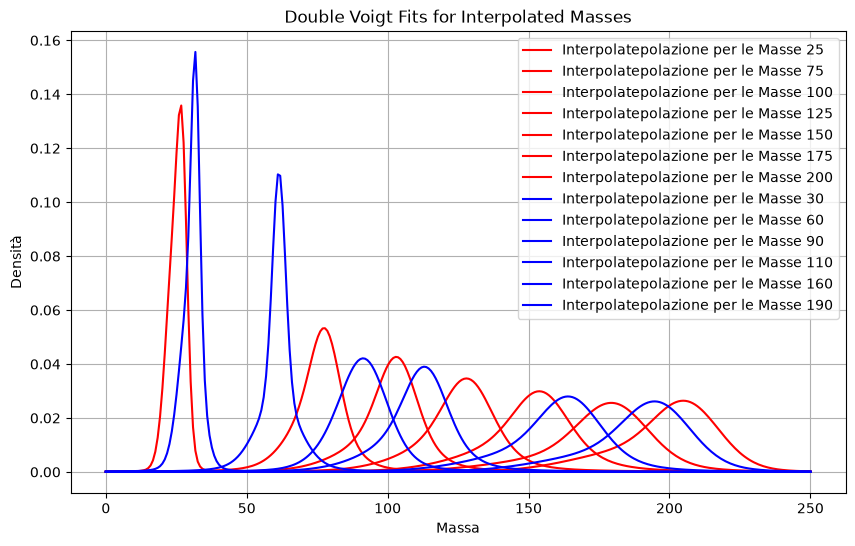

In [5]:
DoubleVoigt_MH30=DoubleVoigtFit(30, fit_MH_values, color='blue')
DoubleVoigt_MH60=DoubleVoigtFit(60, fit_MH_values, color='blue')
DoubleVoigt_MH90=DoubleVoigtFit(90, fit_MH_values, color='blue')
DoubleVoigt_MH110=DoubleVoigtFit(110, fit_MH_values, color='blue')
DoubleVoigt_MH160=DoubleVoigtFit(160, fit_MH_values, color='blue')
DoubleVoigt_MH190=DoubleVoigtFit(190, fit_MH_values, color='blue')

plt.figure(figsize=(20, 12))
DoubleVoigt_MH30.grafico(ax=ax,color='orange')
DoubleVoigt_MH60.grafico(ax=ax,color='blue')
DoubleVoigt_MH90.grafico(ax=ax,color='blue')     
DoubleVoigt_MH110.grafico(ax=ax,color='blue')
DoubleVoigt_MH160.grafico(ax=ax,color='blue')
DoubleVoigt_MH190.grafico(ax=ax,color='blue')
plt.title('Double Voigt Fits for Interpolated Masses')
plt.show()

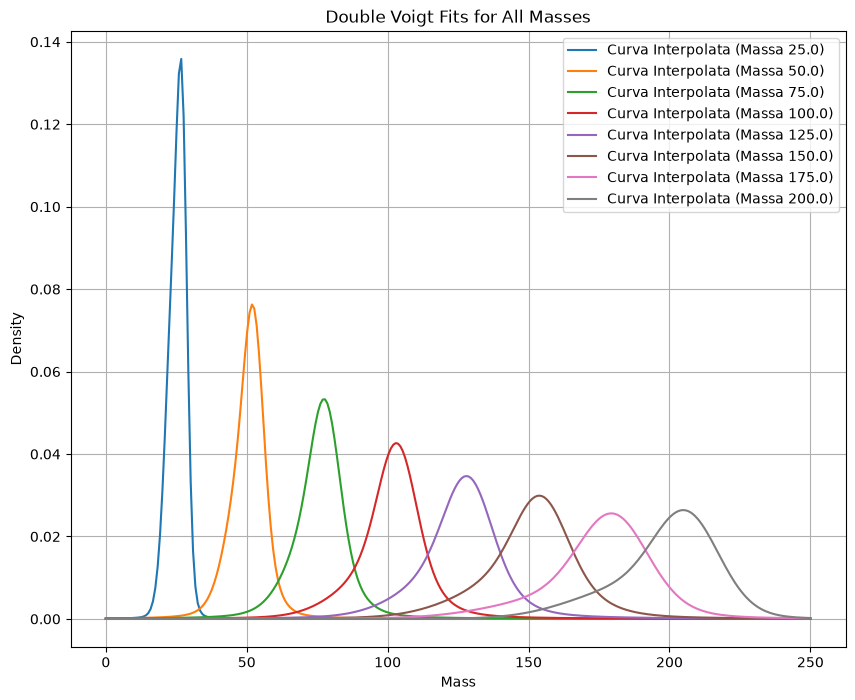

In [6]:
from Utilities_copy import DoubleVoigtFit2
fig, ax= plt.subplots(figsize=(10, 8))
masse_dataset=[float(k.replace("MH", "")) for k in fit_MH_values.keys() if str(k).startswith("MH")]

for m in masse_dataset:
    double_voigt_fit = DoubleVoigtFit2(m, fit_MH_values, ax=ax)
    double_voigt_fit.grafico()

ax.set_title('Double Voigt Fits for All Masses')
ax.set_xlabel('Mass')
ax.set_ylabel('Density')
#ax.legend()
ax.grid(True)
plt.show()

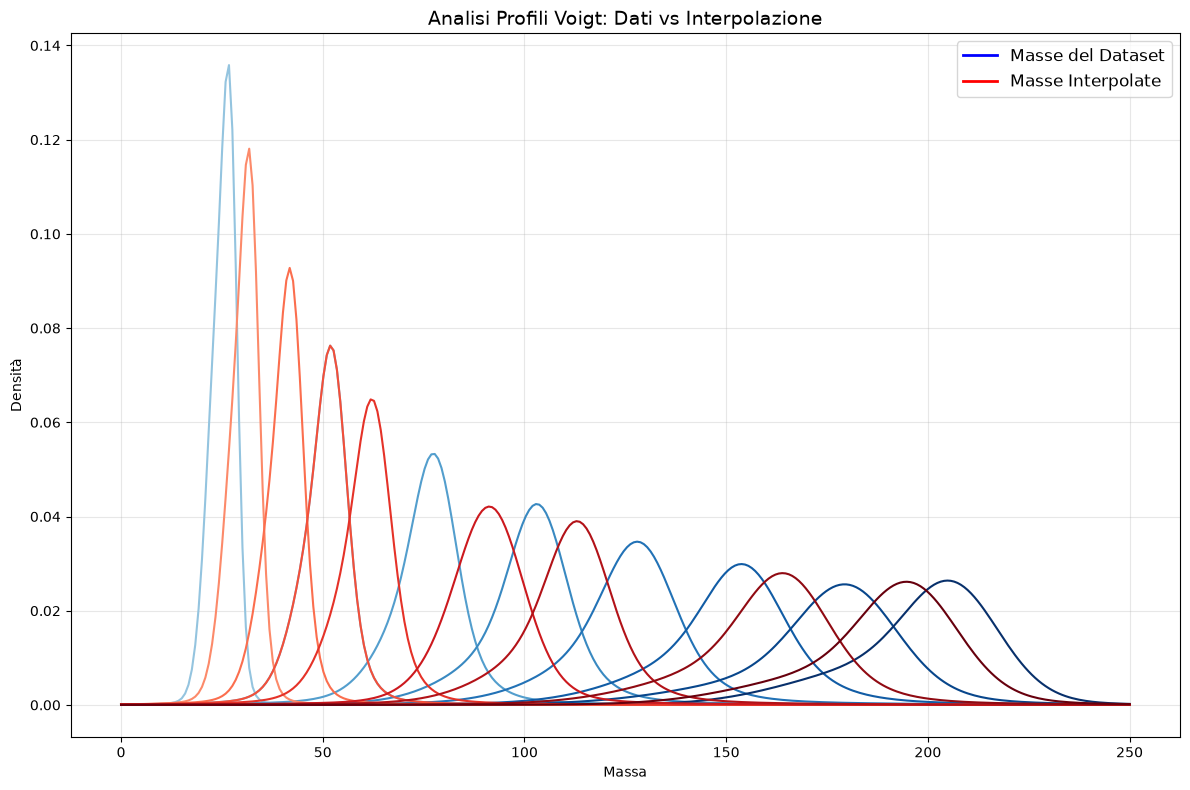

In [7]:
import matplotlib.cm as cm
from matplotlib.lines import Line2D


masse_interpolate=[30, 40, 50, 60, 90, 110, 160, 190]
fig, ax = plt.subplots(figsize=(12, 8))
# Define a colormap
colori_blu=cm.Blues(np.linspace(0.4, 1, len(masse_dataset)))
colori_rossi=cm.Reds(np.linspace(0.4, 1, len(masse_dataset)))

for i, m in enumerate(masse_dataset):
    double_voigt_fit = DoubleVoigtFit2(m, fit_MH_values, ax=ax, color=colori_blu[i])
    double_voigt_fit.grafico()

for i, m in enumerate(masse_interpolate):
    double_voigt_fit = DoubleVoigtFit2(m, fit_MH_values, ax=ax, color=colori_rossi[i])
    double_voigt_fit.grafico()  

# Create custom legend
legend_elements = [Line2D([0], [0], color='blue', lw=2, label='Masse del Dataset'),
                   Line2D([0], [0], color='red', lw=2, label='Masse Interpolate')]

ax.legend(handles=legend_elements, fontsize=12)

ax.set_title("Analisi Profili Voigt: Dati vs Interpolazione", fontsize=14)
ax.set_xlabel("Massa")
ax.set_ylabel("Densità")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<>:30: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:30: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_53321/2367194594.py:30: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  legend_elements = [Line2D([1], [0], color=colori[i], lw=2, label=f"$\phi${25+25*i} GeV") for i in range(len(masse_dataset))]


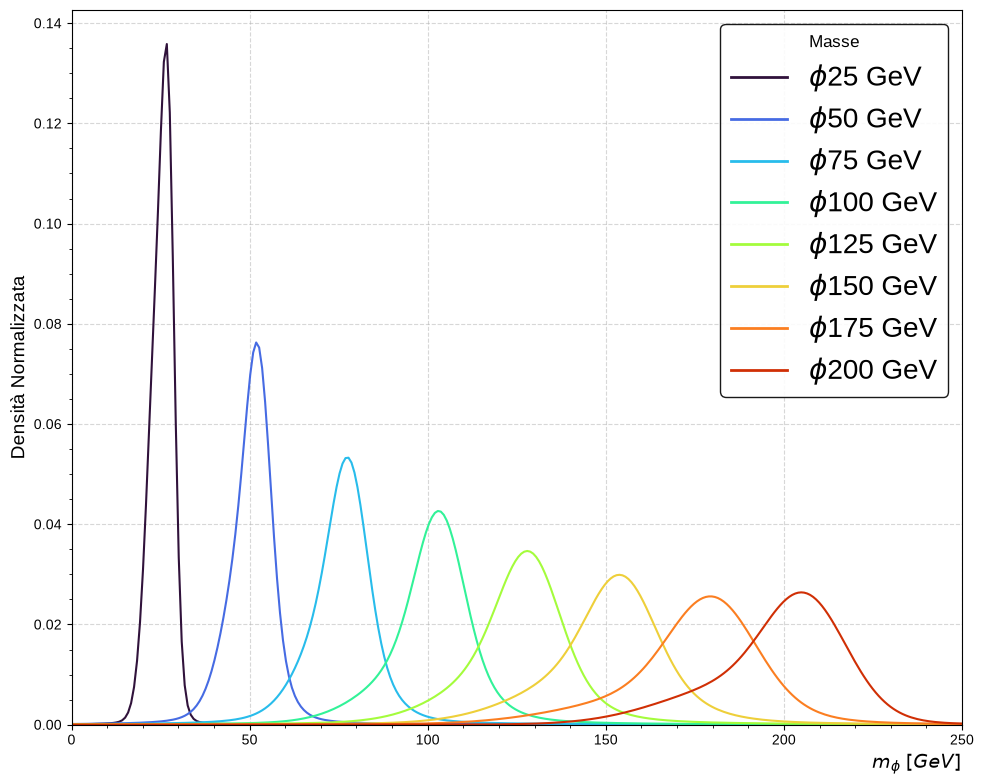

In [8]:
#Proviamo ora a fare dei grafici più carini da inserire nell atesi 
from matplotlib.ticker import AutoMinorLocator
fig, ax= plt.subplots(figsize=(10, 8))
masse_dataset=[float(k.replace("MH", "")) for k in fit_MH_values.keys() if str(k).startswith("MH")]
colori=[plt.cm.turbo(i/len(masse_dataset)) for i in range(len(masse_dataset))]

for i, m in enumerate(masse_dataset):
    double_voigt_fit = DoubleVoigtFit2(m, fit_MH_values, ax=ax, color=colori[i])
    double_voigt_fit.grafico()


plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'DejaVu Sans'],
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.5,
})
ax.set_title("")
#ax.text(0.95, 0.95, 'Doppio Fit di Voigt per Tutte le Masse', fontsize=16, fontweight='bold', ha="right", va="top", transform=ax.transAxes)
ax.set_xlabel(r'$m_{\phi}$ $[GeV]$', fontsize=14, loc='right')
ax.set_ylabel('Densità Normalizzata', fontsize=14)
legend_elements = [Line2D([1], [0], color=colori[i], lw=2, label=f"$\phi${25+25*i} GeV") for i in range(len(masse_dataset))]
ax.legend(handles=legend_elements, loc='upper right', frameon=True, fontsize=20, framealpha=0.9, edgecolor='black', title='Masse', title_fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_ylim(bottom=0) 
ax.set_xlim(0, 250) 
plt.tight_layout()
plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Grafici_Totali.png', bbox_inches='tight')
plt.show()

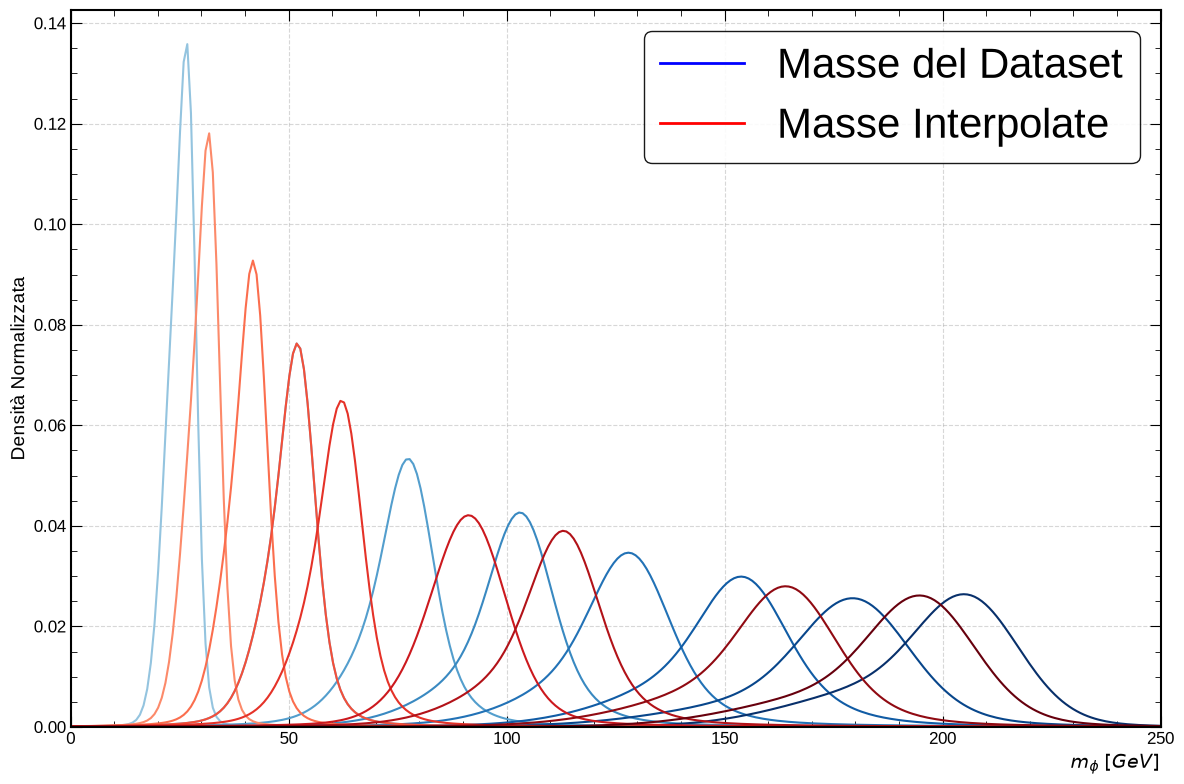

In [9]:
masse_interpolate=[30, 40, 50, 60, 90, 110, 160, 190]
fig, ax = plt.subplots(figsize=(12, 8))
# Define a colormap
colori_blu=cm.Blues(np.linspace(0.4, 1, len(masse_dataset)))
colori_rossi=cm.Reds(np.linspace(0.4, 1, len(masse_dataset)))

for i, m in enumerate(masse_dataset):
    double_voigt_fit = DoubleVoigtFit2(m, fit_MH_values, ax=ax, color=colori_blu[i])
    double_voigt_fit.grafico()

for i, m in enumerate(masse_interpolate):
    double_voigt_fit = DoubleVoigtFit2(m, fit_MH_values, ax=ax, color=colori_rossi[i])
    double_voigt_fit.grafico()  

# Create custom legend
legend_elements = [Line2D([0], [0], color='blue', lw=2, label='Masse del Dataset'),
                   Line2D([0], [0], color='red', lw=2, label='Masse Interpolate')]

ax.legend(handles=legend_elements, fontsize=30, loc='upper right', frameon=True, framealpha=0.9, edgecolor='black')

plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'DejaVu Sans'],
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.5,
})
ax.set_title("")
#ax.text(0.95, 0.95, 'Masse con Interpolazioni', fontsize=16, fontweight='bold', ha="right", va="top", transform=ax.transAxes)
ax.set_xlabel(r'$m_{\phi}$ $[GeV]$', fontsize=14, loc='right')
ax.set_ylabel('Densità Normalizzata', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_ylim(bottom=0) 
ax.set_xlim(0, 250) 
plt.tight_layout()
plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Grafico_Interpolazioni.png', bbox_inches='tight')
plt.show()

<>:24: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:25: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:26: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:27: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:24: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:25: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:26: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences wil

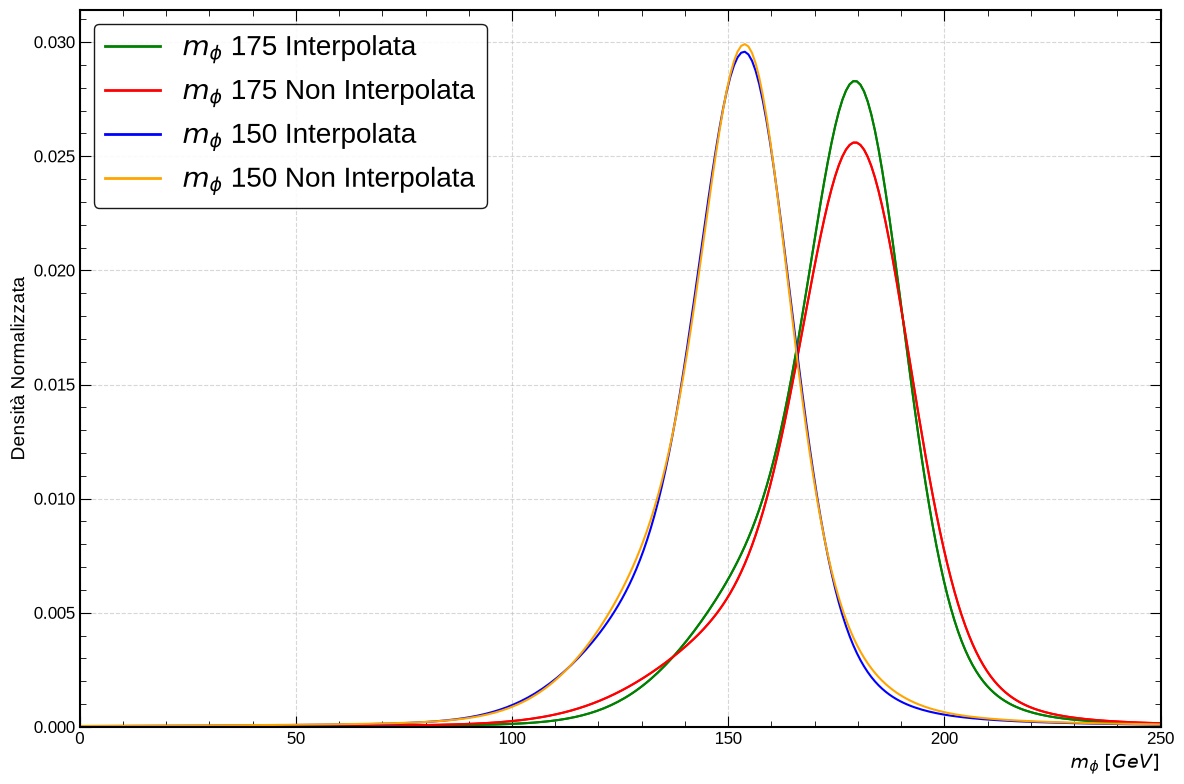

In [10]:
#Ora facciamo il grafico di 175 GeV escludendo i suoi dati e interpolando i valori dei fit delle altre masse
from Utilities_copy import DoubleVoigtFit3
fig, ax = plt.subplots(figsize=(12, 8))

fit_Interpolated_175_3=DoubleVoigtFit3(175, fit_MH_values, exclude_mass=[50, 175], ax=ax, color='green')
fit_non_Interpolated_175_3=DoubleVoigtFit3(175, fit_MH_values, ax=ax, color='red')

fit_Interpolated_175_3.grafico()
fit_non_Interpolated_175_3.grafico()

fit_Interpolated_175=DoubleVoigtFit2(175, fit_MH_values, exclude_mass=[50, 175], ax=ax, color='green')
fit_non_Interpolated_175=DoubleVoigtFit2(175, fit_MH_values, ax=ax, color='red')


fit_Interpolated_150=DoubleVoigtFit2(150, fit_MH_values, exclude_mass=[50, 150], ax=ax, color='blue')
fit_non_Interpolated_150=DoubleVoigtFit2(150, fit_MH_values, ax=ax, color='orange')

fit_Interpolated_175.grafico()
fit_non_Interpolated_175.grafico()
fit_Interpolated_150.grafico()
fit_non_Interpolated_150.grafico()


legend_elements = [Line2D([0], [0], color='green', lw=2, label='$m_{\phi}$ 175 Interpolata'),
                   Line2D([0], [0], color='red', lw=2, label='$m_{\phi}$ 175 Non Interpolata')
                   ,Line2D([0], [0], color='blue', lw=2, label='$m_{\phi}$ 150 Interpolata'),
                     Line2D([0], [0], color='orange', lw=2, label='$m_{\phi}$ 150 Non Interpolata')]

ax.legend(handles=legend_elements, fontsize=20, loc='upper left', frameon=True, framealpha=0.9, edgecolor='black')

plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'DejaVu Sans'],
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.5,
})
ax.set_title("")
#ax.text(0.95, 0.95, 'Masse con Interpolazioni', fontsize=16, fontweight='bold', ha="right", va="top", transform=ax.transAxes)
ax.set_xlabel(r'$m_{\phi}$ $[GeV]$', fontsize=14, loc='right')
ax.set_ylabel('Densità Normalizzata', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_ylim(bottom=0) 
ax.set_xlim(0, 250) 
plt.tight_layout()
#plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Grafico_Interpolazioni.png', bbox_inches='tight')
plt.show()

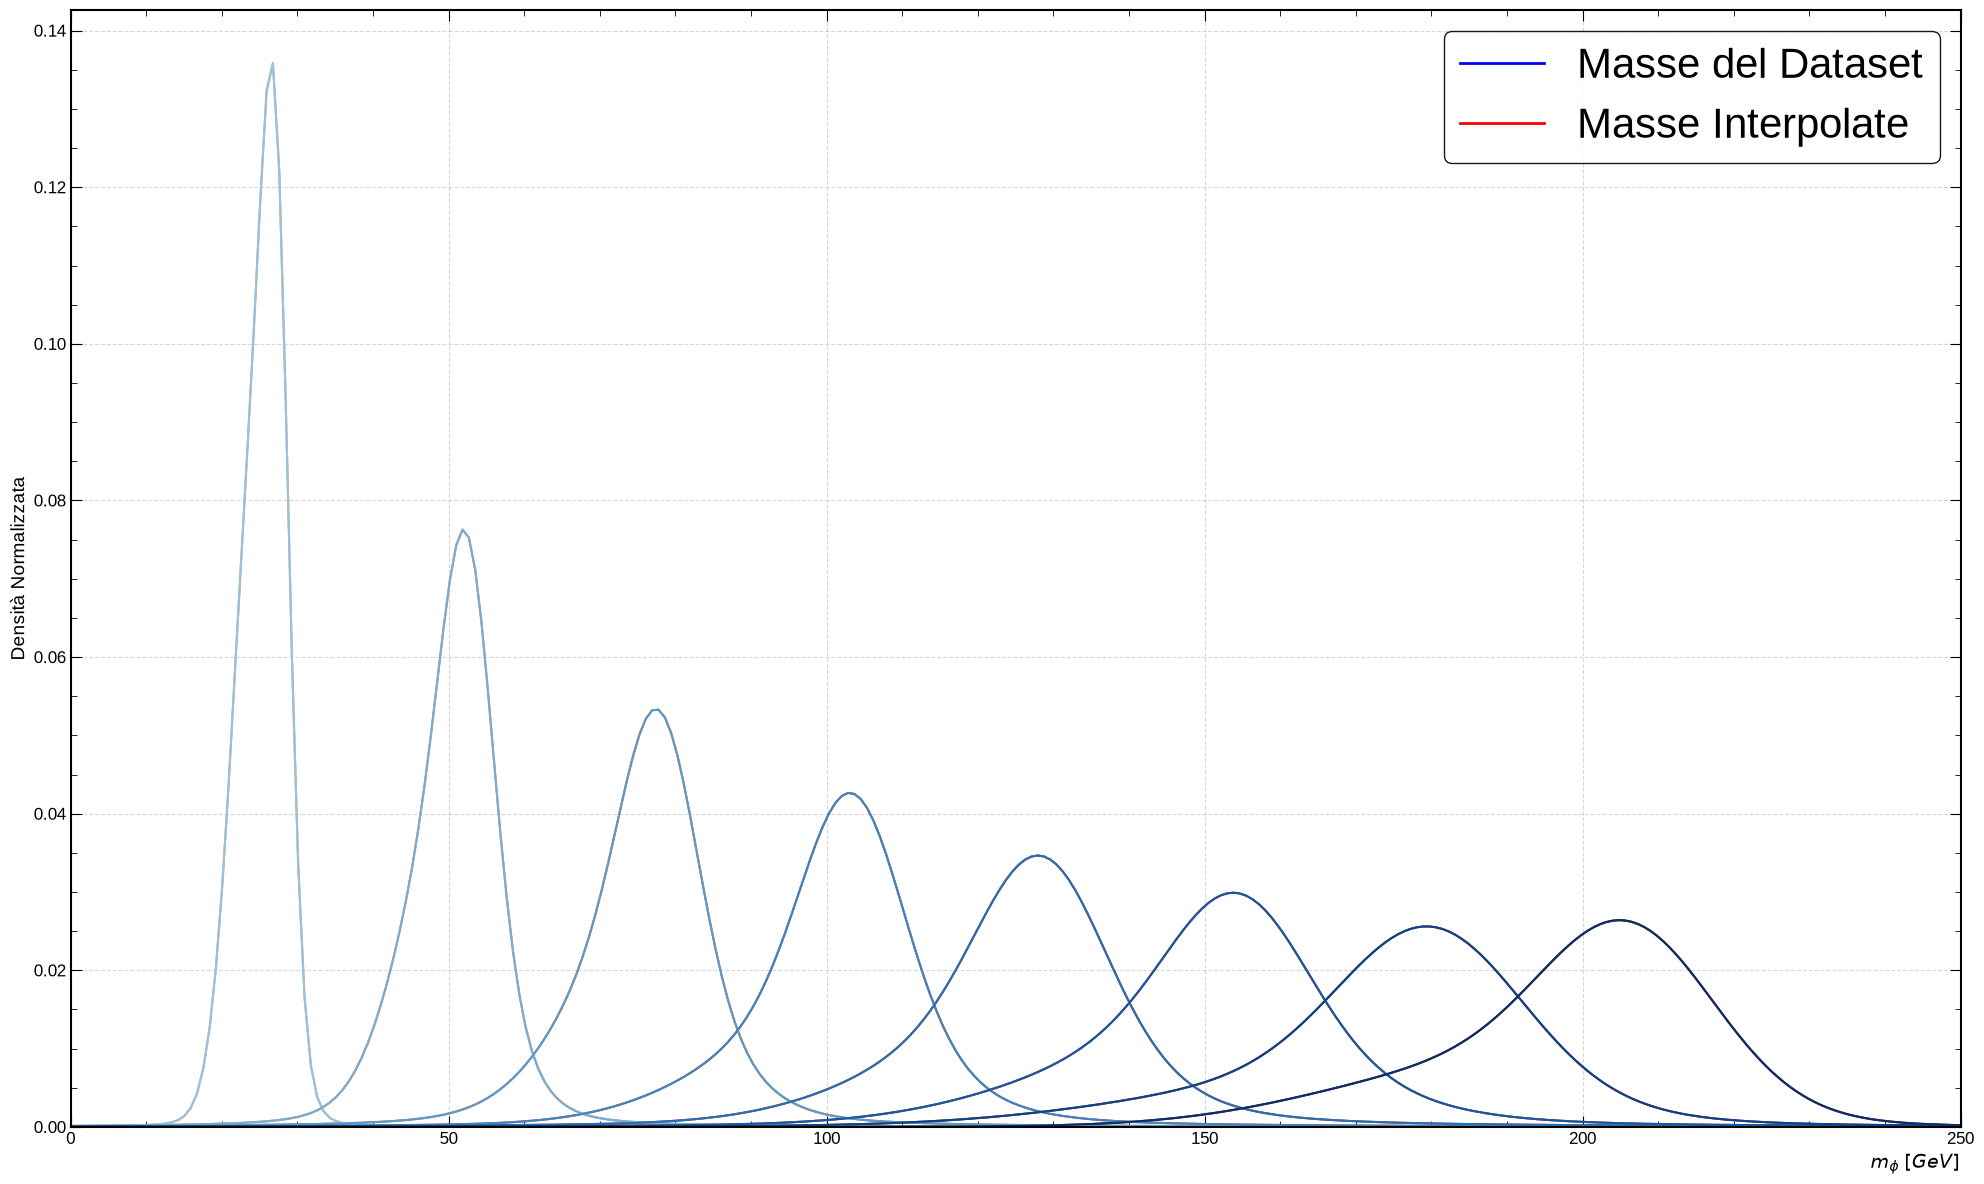

In [11]:
#Ora facciamolo per tutti con un ciclo for
fig, ax = plt.subplots(figsize=(20, 12))

for i, m in enumerate(masse_dataset):
    double_voigt_fit_interpolato = DoubleVoigtFit2(m, fit_MH_values, exclude_mass=[50, m], ax=ax, color=colori_rossi[i])
    double_voigt_fit_interpolato.grafico()
    

for i, m in enumerate(masse_dataset):    
    double_voigt_fit_non_interpolato = DoubleVoigtFit2(m, fit_MH_values, ax=ax, color=colori_blu[i])
    double_voigt_fit_non_interpolato.grafico()
    

legend_elements = [Line2D([0], [0], color='blue', lw=2, label='Masse del Dataset'),
                   Line2D([0], [0], color='red', lw=2, label='Masse Interpolate')]

ax.legend(handles=legend_elements, fontsize=30, loc='upper right', frameon=True, framealpha=0.9, edgecolor='black')

plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'DejaVu Sans'],
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.5,
})
ax.set_title("")
#ax.text(0.95, 0.95, 'Masse con Interpolazioni', fontsize=16, fontweight='bold', ha="right", va="top", transform=ax.transAxes)
ax.set_xlabel(r'$m_{\phi}$ $[GeV]$', fontsize=14, loc='right')
ax.set_ylabel('Densità Normalizzata', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_ylim(bottom=0) 
ax.set_xlim(0, 250) 
plt.tight_layout()
plt.show()

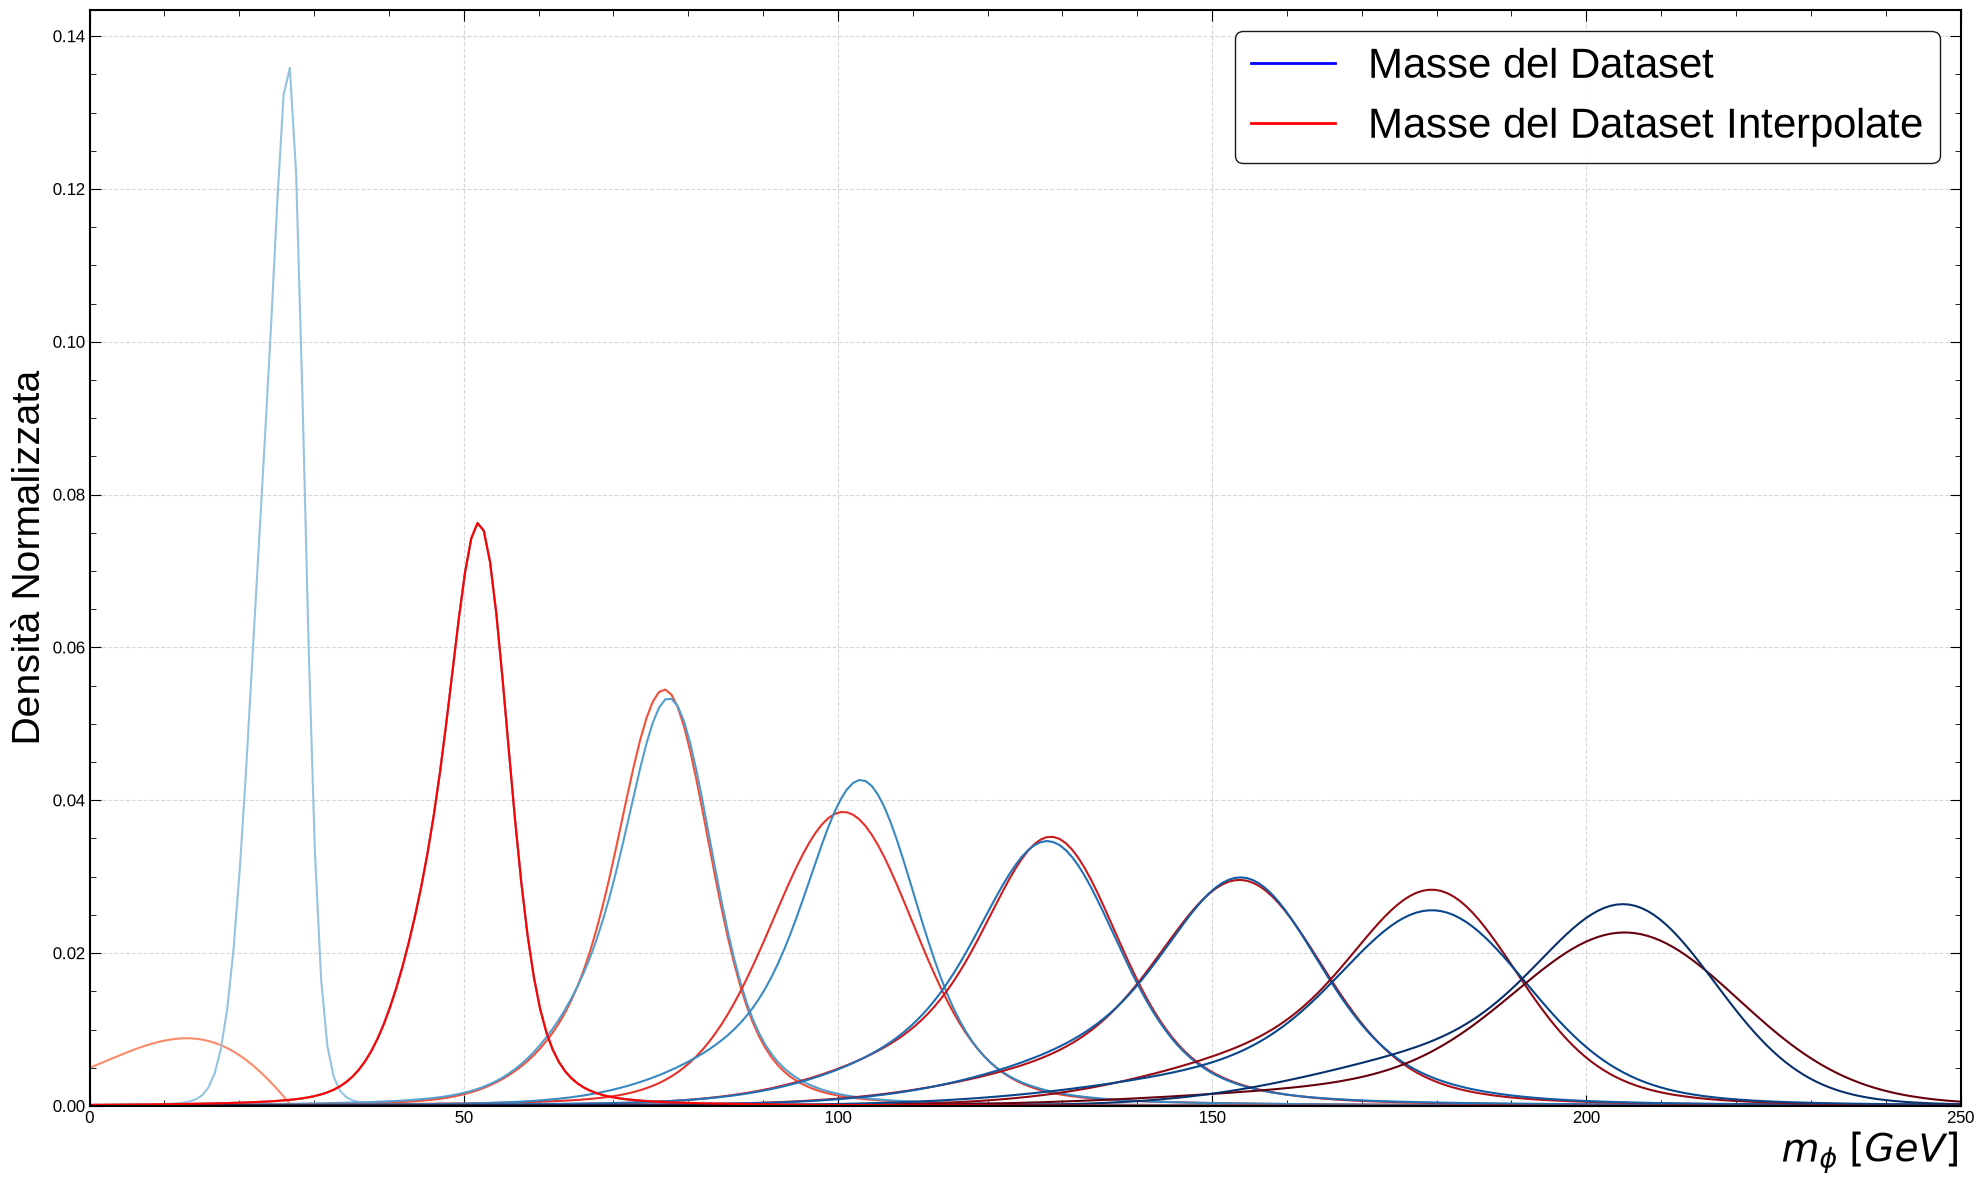

In [25]:
#Ora facciamolo per tutti con un ciclo for
from Utilities_copy import DoubleVoigtFit3


fig, ax = plt.subplots(figsize=(20, 12))

for i, m in enumerate(masse_dataset):
    double_voigt_fit_interpolato = DoubleVoigtFit3(m, fit_MH_values, exclude_mass=[50, m], ax=ax, color=colori_rossi[i])
    double_voigt_fit_interpolato.grafico()    
    double_voigt_fit_non_interpolato = DoubleVoigtFit3(m, fit_MH_values, exclude_mass=[50], ax=ax, color=colori_blu[i])
    double_voigt_fit_non_interpolato.grafico()
    
double_voigt_fit_non_interpolato = DoubleVoigtFit3(50, fit_MH_values, exclude_mass=[50], ax=ax, color="red")
double_voigt_fit_non_interpolato.grafico()

legend_elements = [Line2D([0], [0], color='blue', lw=2, label='Masse del Dataset'),
                   Line2D([0], [0], color='red', lw=2, label='Masse del Dataset Interpolate')]

ax.legend(handles=legend_elements, fontsize=30, loc='upper right', frameon=True, framealpha=0.9, edgecolor='black')

plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'DejaVu Sans'],
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.5,
})
ax.set_title("")
#ax.text(0.95, 0.95, 'Masse con Interpolazioni', fontsize=16, fontweight='bold', ha="right", va="top", transform=ax.transAxes)
ax.set_xlabel(r'$m_{\phi}$ $[GeV]$', fontsize=28, loc='right')
ax.set_ylabel('Densità Normalizzata', fontsize=28)
ax.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_ylim(bottom=0) 
ax.set_xlim(0, 250) 
plt.tight_layout()
plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Grafico_Prova_Interpolazioni_Tot.png', bbox_inches='tight')
plt.show()

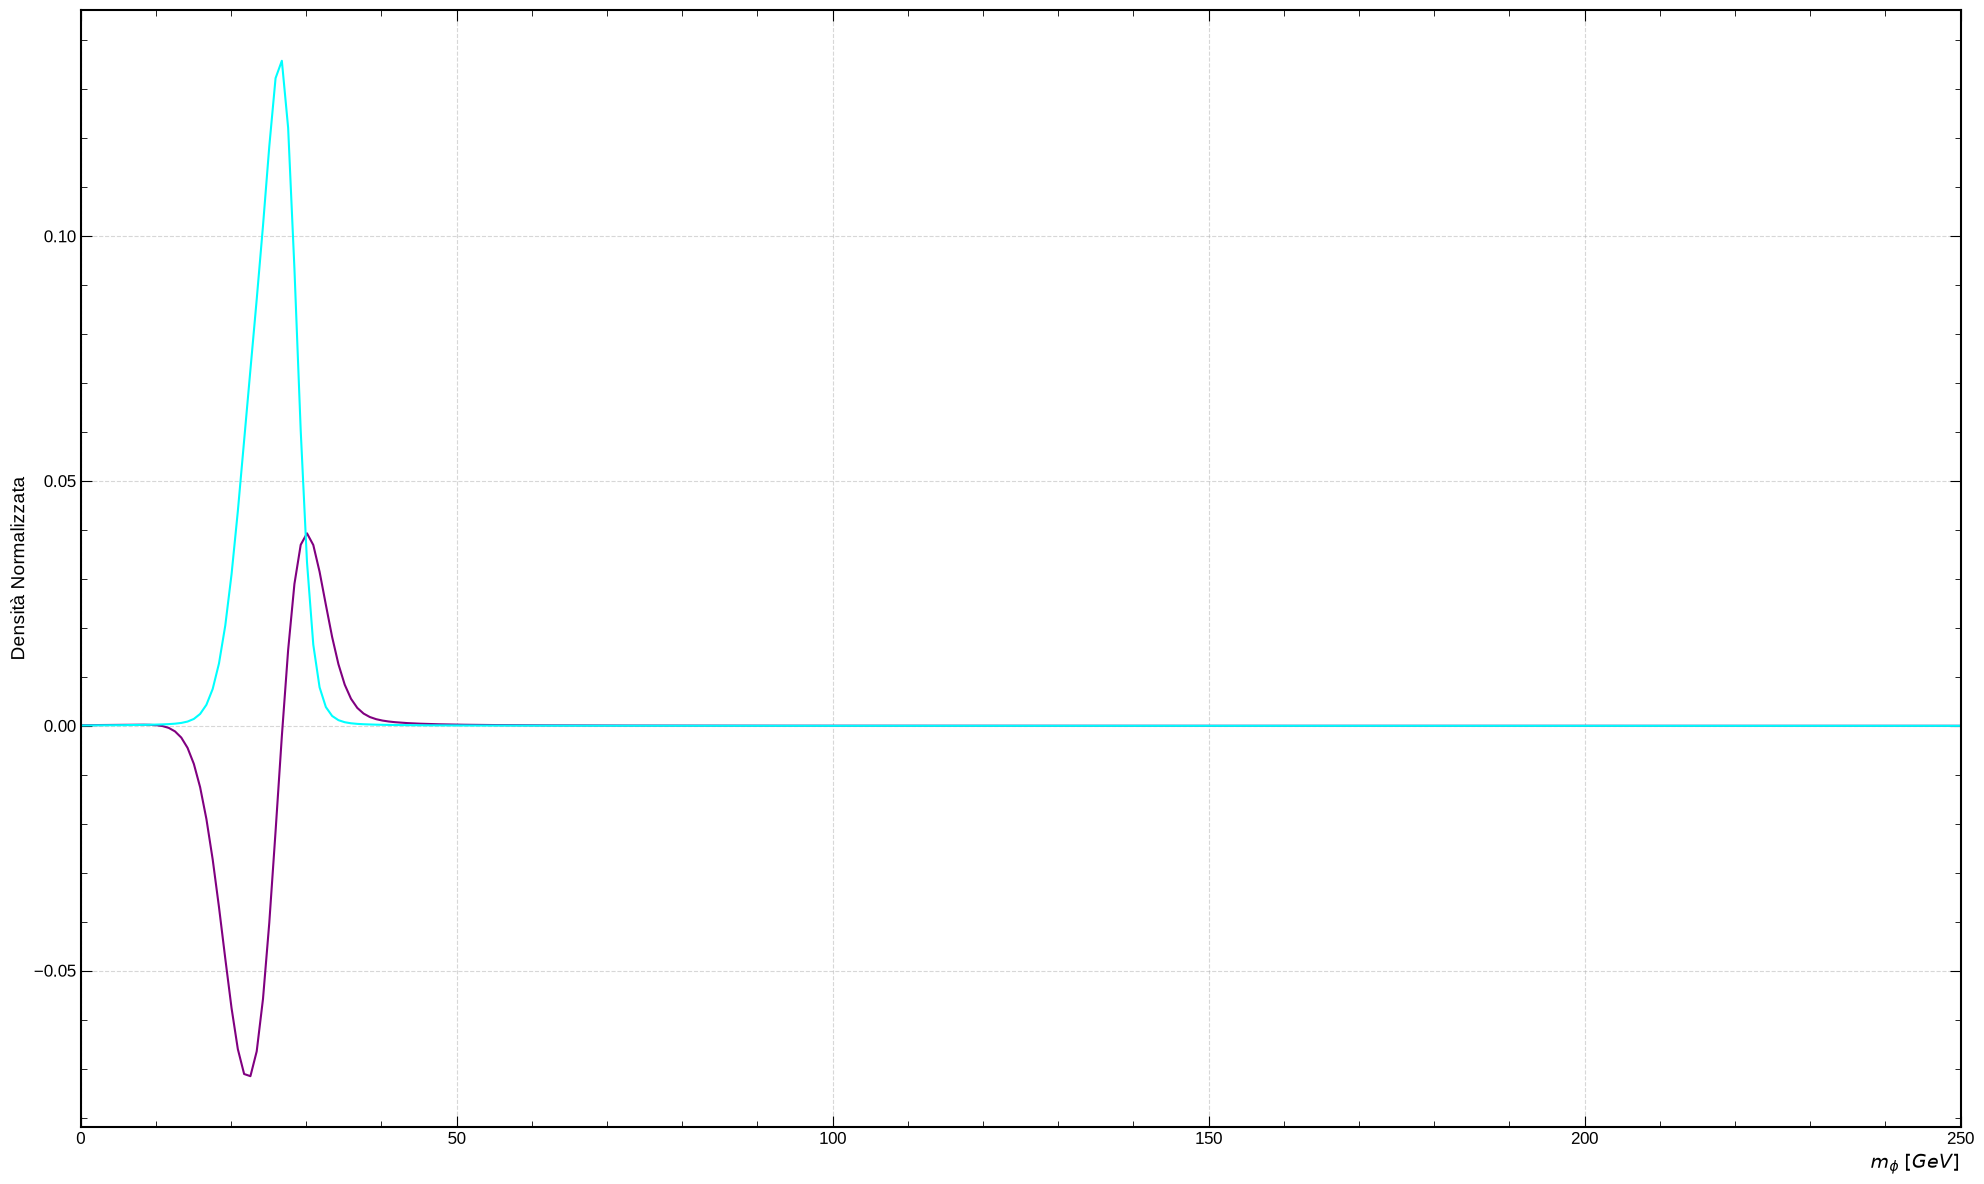

Fit Parameters for Mass 25 (Interpolated): {'norm': np.float64(0.46956416197620887), 'mu': np.float64(28.861664194879864), 'sigma': np.float64(2.813188087556558), 'gamma': np.float64(0.7002883737766092), 'norm2': np.float64(0.7413253138150924), 'mu2': np.float64(22.869013713995226), 'sigma2': np.float64(-3.679363921026201), 'gamma2': np.float64(0.001)}


In [13]:
fig, ax= plt.subplots(figsize=(20,12))

fit_interpolato_25=DoubleVoigtFit3(25, fit_MH_values, exclude_mass=[25], ax=ax, color='purple')
fit_non_Interpolated_25=DoubleVoigtFit3(25, fit_MH_values, exclude_mass=[50], ax=ax, color='cyan')
fit_interpolato_25.grafico()
fit_non_Interpolated_25.grafico()

plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'DejaVu Sans'],
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.5,
})
ax.set_title("")
#ax.text(0.95, 0.95, 'Masse con Interpolazioni', fontsize=16, fontweight='bold', ha="right", va="top", transform=ax.transAxes)
ax.set_xlabel(r'$m_{\phi}$ $[GeV]$', fontsize=14, loc='right')
ax.set_ylabel('Densità Normalizzata', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
#ax.set_ylim(bottom=0) 
ax.set_xlim(0, 250) 
plt.tight_layout()
plt.show()

fit_parameters=fit_interpolato_25.get_fit_parameters()

print(f"Fit Parameters for Mass 25 (Interpolated): {fit_parameters}")

In [14]:
prova_rms_125=DoubleVoigtFit3(125, fit_MH_values, exclude_mass=[50, 125])
prova_rms_125_org=DoubleVoigtFit3(125, fit_MH_values)

parametri_interpolati_125 = prova_rms_125.get_fit_parameters()
parametri_originali_125 = prova_rms_125_org.get_fit_parameters()

x_prova = np.linspace(0, 250, 300)
y_interpolati_125 = voigt2(x_prova, parametri_interpolati_125["norm"], parametri_interpolati_125["mu"], parametri_interpolati_125["sigma"], parametri_interpolati_125["gamma"], parametri_interpolati_125["norm2"], parametri_interpolati_125["mu2"], parametri_interpolati_125["sigma2"], parametri_interpolati_125["gamma2"])
y_orinali_125 = voigt2(x_prova, parametri_originali_125["norm"], parametri_originali_125["mu"], parametri_originali_125["sigma"], parametri_originali_125["gamma"], parametri_originali_125["norm2"], parametri_originali_125["mu2"], parametri_originali_125["sigma2"], parametri_originali_125["gamma2"]) 


#Calcolo dello scarto quadratico medio (RMSE) tra i valori interpolati e quelli originali
rmse_125 = np.sqrt(np.mean((y_interpolati_125 - y_orinali_125) ** 2))
print(f"RMSE tra i valori interpolati e quelli originali per la massa 125 GeV: {rmse_125:.6f}") 

#Calcolo MSE tra i valori interpolati e quelli originali
mse_125 = np.mean((y_interpolati_125 - y_orinali_125) ** 2)
print(f"MSE tra i valori interpolati e quelli originali per la massa 125 GeV: {mse_125:.6f}")


RMSE tra i valori interpolati e quelli originali per la massa 125 GeV: 0.000294
MSE tra i valori interpolati e quelli originali per la massa 125 GeV: 0.000000


In [15]:
# 1. Calcolo del modello interpolato (escludendo la massa 125)
prova_rms_125 = DoubleVoigtFit3(125, fit_MH_values, exclude_mass=[50, 125])
parametri_interpolati_125 = prova_rms_125.get_fit_parameters()

# 2. Recupero diretto dei parametri originali (veri)
parametri_originali_125 = fit_MH_values["MH125"]

# 3. Generazione delle curve
x_prova = np.linspace(0, 250, 300)

# Unpacking per i parametri interpolati
y_interpolati_125 = voigt2(x_prova, *parametri_interpolati_125.values())

# Assicurati di estrarre i parametri originali nello stesso ordine richiesto da voigt2
args_originali = [parametri_originali_125[p] for p in prova_rms_125.param_names]
y_originali_125 = voigt2(x_prova, *args_originali) 

# 4. Calcolo degli errori
rmse_125 = np.sqrt(np.mean((y_interpolati_125 - y_originali_125) ** 2))
mse_125 = np.mean((y_interpolati_125 - y_originali_125) ** 2)

print(f"RMSE (Massa 125 GeV): {rmse_125:.6f}") 
print(f"MSE (Massa 125 GeV): {mse_125:.6f}")

RMSE (Massa 125 GeV): 0.000294
MSE (Massa 125 GeV): 0.000000


Massa  25 GeV -> RMSE: 0.019375 | MSE: 0.000375
Massa  75 GeV -> RMSE: 0.000623 | MSE: 0.000000
Massa 100 GeV -> RMSE: 0.001734 | MSE: 0.000003
Massa 125 GeV -> RMSE: 0.000294 | MSE: 0.000000
Massa 150 GeV -> RMSE: 0.000157 | MSE: 0.000000
Massa 175 GeV -> RMSE: 0.000693 | MSE: 0.000000
Massa 200 GeV -> RMSE: 0.001192 | MSE: 0.000001
Media RMSE: 0.003438


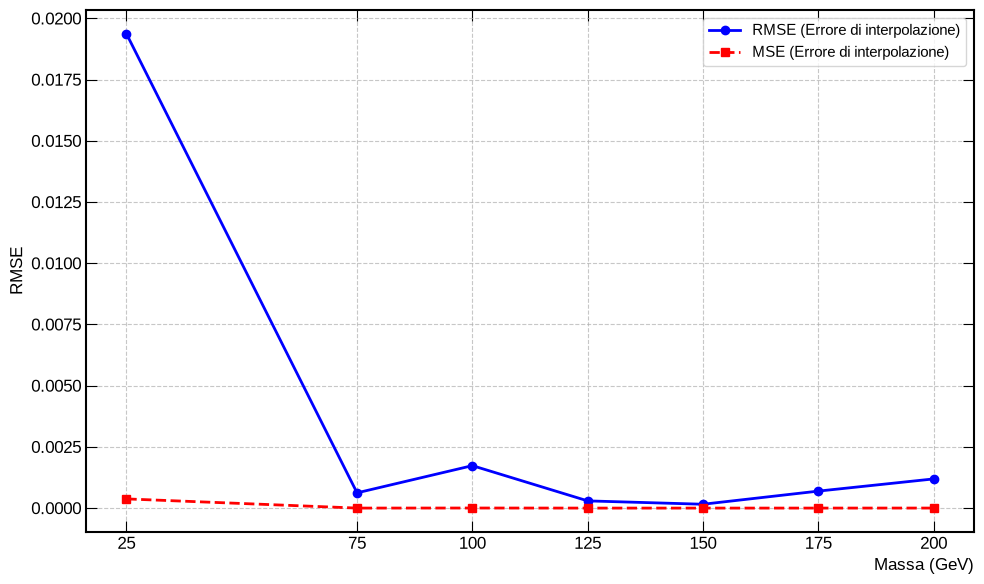

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Liste per salvare i dati per il grafico
masse_testate = []
rmse_valori = []
mse_valori = []

# Asse X comune per la generazione delle curve
x_prova = np.linspace(0, 250, 300)

# Ciclo su tutte le masse presenti nel dizionario originale
for k, parametri_originali in fit_MH_values.items():
    if k.startswith("MH"):
        massa_corrente = float(k.replace("MH", ""))
        
        # Saltiamo la massa 50 se è quella che escludi sempre a prescindere dai tuoi dati base
        if massa_corrente == 50.0:
            continue
            
        masse_testate.append(massa_corrente)
        
        # 1. Modello interpolato (escludiamo la massa 50 di default + la massa corrente)
        modello_interpolato = DoubleVoigtFit3(
            mass=massa_corrente, 
            fit_values=fit_MH_values, 
            exclude_mass=[50, massa_corrente]
        )
        parametri_interpolati = modello_interpolato.get_fit_parameters()
        
        # 2. Estraiamo gli argomenti nell'ordine corretto per voigt2
        param_names = modello_interpolato.param_names
        args_interpolati = [parametri_interpolati[p] for p in param_names]
        args_originali = [parametri_originali[p] for p in param_names]
        
        # 3. Generazione delle distribuzioni
        y_interpolati = voigt2(x_prova, *args_interpolati)
        y_originali = voigt2(x_prova, *args_originali)
        
        # 4. Calcolo degli errori
        mse = np.mean((y_interpolati - y_originali) ** 2)
        rmse = np.sqrt(mse)
        
        # Salvataggio dei risultati
        mse_valori.append(mse)
        rmse_valori.append(rmse)
        
        # Stampa a schermo per monitorare l'avanzamento
        print(f"Massa {massa_corrente:3.0f} GeV -> RMSE: {rmse:.6f} | MSE: {mse:.6f}")

# ---------------------------------------------------------
# GRAFICO DEGLI SCARTI IN FUNZIONE DELLA MASSA
# ---------------------------------------------------------

# Assicuriamoci che le liste siano ordinate per massa crescente per un grafico corretto
masse_ordinate, rmse_ordinati = zip(*sorted(zip(masse_testate, rmse_valori)))

plt.figure(figsize=(10, 6))

plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'DejaVu Sans'],
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.5,
})

# Plot dell'RMSE
plt.plot(masse_ordinate, rmse_ordinati, marker='o', linestyle='-', color='b', label='RMSE (Errore di interpolazione)', linewidth=2)
#Plot della MSE
plt.plot(masse_ordinate, mse_valori, marker='s', linestyle='--', color='r', label='MSE (Errore di interpolazione)', linewidth=2)

plt.xlabel("Massa (GeV)", fontsize=12, loc='right')
plt.ylabel("RMSE", fontsize=12)

# Abbellimenti del grafico
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(masse_ordinate) # Mostra esattamente i tick corrispondenti alle tue masse
plt.legend(fontsize=11)

#Stampiamo a schermo anche la media delgi RMSE
media_rmse = np.mean(rmse_ordinati)
print(f"Media RMSE: {media_rmse:.6f}")

plt.tight_layout()
plt.show()

<>:30: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:30: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_53321/3135602689.py:30: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  ax2.set_xlabel('$m_{\phi}$ [Gev]', fontsize=24, loc='right')


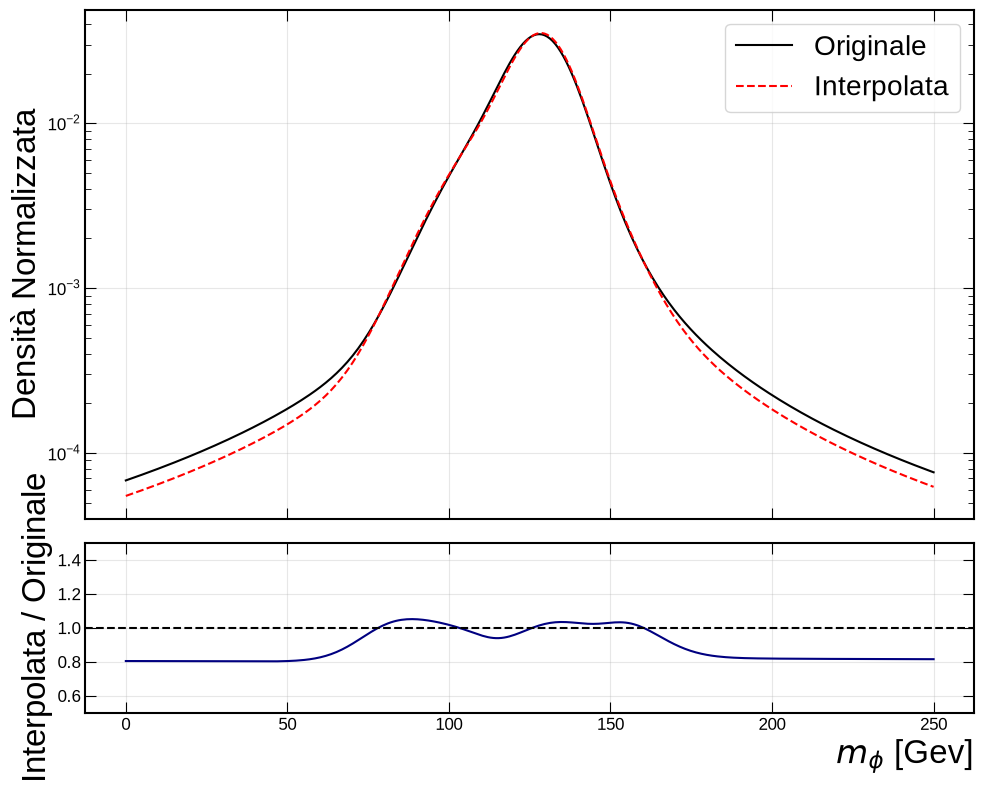

Rapporto delle aree: 0.9960


In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Genera le curve (assumendo tu abbia già y_interpolati_125 e y_originali_125)
x_prova = np.linspace(0, 250, 300)

# Calcolo del rapporto punto a punto
# Aggiungiamo un piccolissimo numero (1e-10) al denominatore per evitare divisioni per zero
rapporto = y_interpolati_125 / (y_originali_125 + 1e-10)

# Creiamo una figura con due pannelli (uno grande sopra, uno piccolo sotto)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# --- PANNELLO SUPERIORE: Le distribuzioni ---
ax1.plot(x_prova, y_originali_125, label='Originale', color='black')
ax1.plot(x_prova, y_interpolati_125, label='Interpolata', color='red', linestyle='--')
ax1.set_ylabel('Densità Normalizzata', fontsize=24)
#ax1.set_title('Confronto Distribuzioni (Massa 125)', fontsize=14)
ax1.set_yscale('log')  # Scala logaritmica per l'asse Y
ax1.legend(fontsize=20)
ax1.grid(True, alpha=0.3)

# --- PANNELLO INFERIORE: Il Rapporto ---
ax2.plot(x_prova, rapporto, color='navy', marker='none', linestyle='-')
ax2.axhline(1, color='black', linestyle='--') # Linea di riferimento a 1 (accordo perfetto)

# Limitiamo l'asse Y del rapporto per ignorare le esplosioni numeriche nelle code
ax2.set_ylim(0.5, 1.5) 
ax2.set_ylabel('Interpolata / Originale', fontsize=24)
ax2.set_xlabel('$m_{\phi}$ [Gev]', fontsize=24, loc='right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Grafico_Rapporto_Interpolazione_125.png', bbox_inches='tight')
plt.show()

area_interpolata = np.sum(y_interpolati_125)
area_originale = np.sum(y_originali_125)
rapporto_globale = area_interpolata / area_originale

print(f"Rapporto delle aree: {rapporto_globale:.4f}")

<>:39: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:39: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_53321/1974059473.py:39: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  ax2.set_xlabel('$m_{\phi}$ [Gev]', fontsize=24, loc='right')


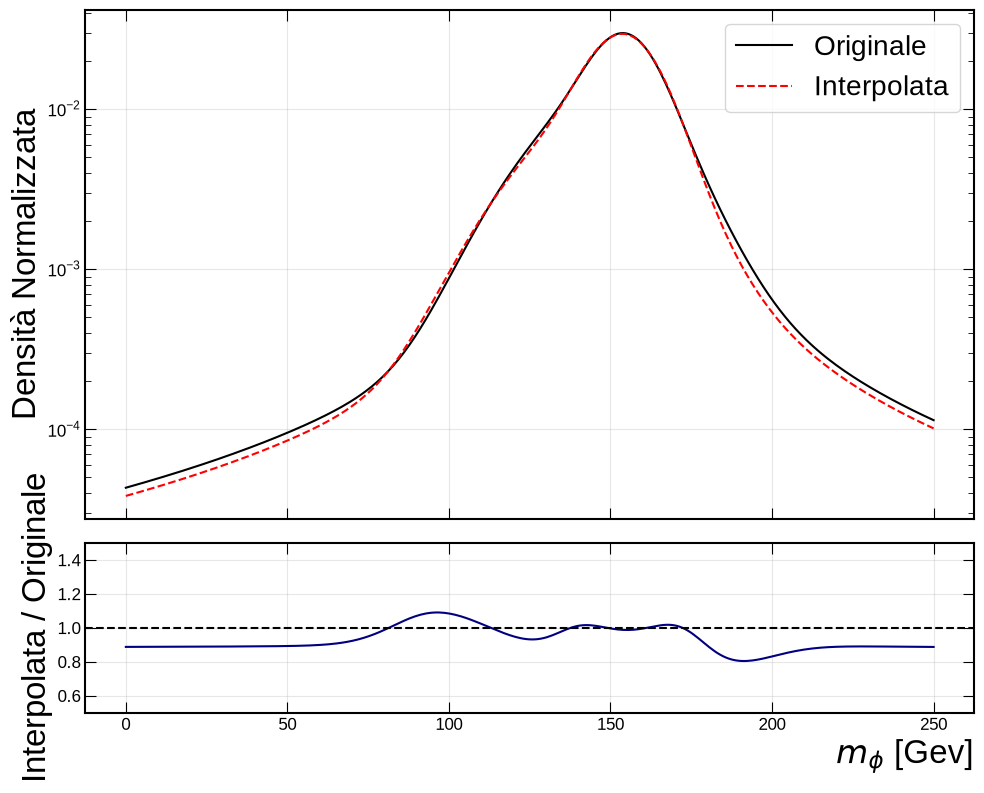

Rapporto delle aree: 0.9881


In [29]:
prova_rms_150=DoubleVoigtFit3(150, fit_MH_values, exclude_mass=[50, 150])
prova_rms_150_org=DoubleVoigtFit3(150, fit_MH_values)

parametri_interpolati_150 = prova_rms_150.get_fit_parameters()
parametri_originali_150 = prova_rms_150_org.get_fit_parameters()

x_prova = np.linspace(0, 250, 300)
y_interpolati_150 = voigt2(x_prova, parametri_interpolati_150["norm"], parametri_interpolati_150["mu"], parametri_interpolati_150["sigma"], parametri_interpolati_150["gamma"], parametri_interpolati_150["norm2"], parametri_interpolati_150["mu2"], parametri_interpolati_150["sigma2"], parametri_interpolati_150["gamma2"])
y_originali_150 = voigt2(x_prova, parametri_originali_150["norm"], parametri_originali_150["mu"], parametri_originali_150["sigma"], parametri_originali_150["gamma"], parametri_originali_150["norm2"], parametri_originali_150["mu2"], parametri_originali_150["sigma2"], parametri_originali_150["gamma2"]) 



# Genera le curve (assumendo tu abbia già y_interpolati_150 e y_originali_150)
x_prova = np.linspace(0, 250, 300)

# Calcolo del rapporto punto a punto
# Aggiungiamo un piccolissimo numero (1e-10) al denominatore per evitare divisioni per zero
rapporto = y_interpolati_150 / (y_originali_150 + 1e-10)

# Creiamo una figura con due pannelli (uno grande sopra, uno piccolo sotto)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# --- PANNELLO SUPERIORE: Le distribuzioni ---
ax1.plot(x_prova, y_originali_150, label='Originale', color='black')
ax1.plot(x_prova, y_interpolati_150, label='Interpolata', color='red', linestyle='--')
ax1.set_ylabel('Densità Normalizzata', fontsize=24)
#ax1.set_title('Confronto Distribuzioni (Massa 150)', fontsize=14)
ax1.set_yscale('log')  # Scala logaritmica per l'asse Y
ax1.legend(fontsize=20)
ax1.grid(True, alpha=0.3)

# --- PANNELLO INFERIORE: Il Rapporto ---
ax2.plot(x_prova, rapporto, color='navy', marker='none', linestyle='-')
ax2.axhline(1, color='black', linestyle='--') # Linea di riferimento a 1 (accordo perfetto)

# Limitiamo l'asse Y del rapporto per ignorare le esplosioni numeriche nelle code
ax2.set_ylim(0.5, 1.5) 
ax2.set_ylabel('Interpolata / Originale', fontsize=24)
ax2.set_xlabel('$m_{\phi}$ [Gev]', fontsize=24, loc='right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Grafico_Rapporto_Interpolazione_150.png', bbox_inches='tight')
plt.show()

area_interpolata = np.sum(y_interpolati_150)
area_originale = np.sum(y_originali_150)
rapporto_globale = area_interpolata / area_originale

print(f"Rapporto delle aree: {rapporto_globale:.4f}")

<>:39: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:39: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_53321/1532313372.py:39: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  ax2.set_xlabel('$m_{\phi}$ [Gev])', fontsize=12, loc='right')


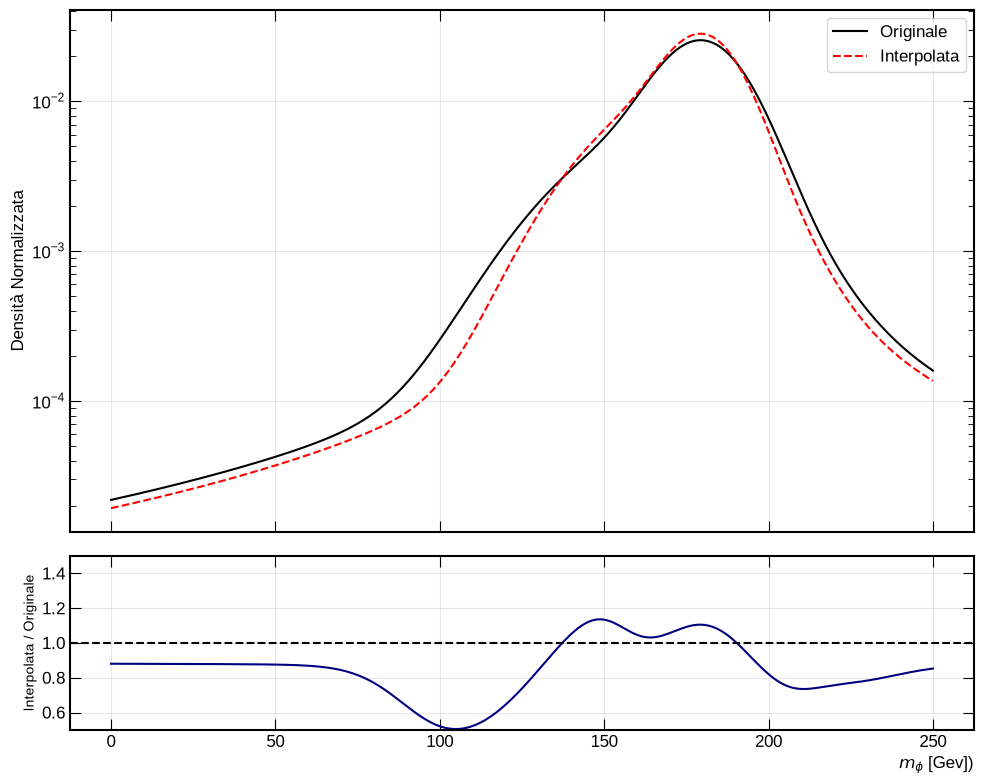

Rapporto delle aree: 1.0180


In [19]:
prova_rms_175=DoubleVoigtFit3(175, fit_MH_values, exclude_mass=[50, 175])
prova_rms_175_org=DoubleVoigtFit3(175, fit_MH_values)

parametri_interpolati_175 = prova_rms_175.get_fit_parameters()
parametri_originali_175 = prova_rms_175_org.get_fit_parameters()

x_prova = np.linspace(0, 250, 300)
y_interpolati_175 = voigt2(x_prova, parametri_interpolati_175["norm"], parametri_interpolati_175["mu"], parametri_interpolati_175["sigma"], parametri_interpolati_175["gamma"], parametri_interpolati_175["norm2"], parametri_interpolati_175["mu2"], parametri_interpolati_175["sigma2"], parametri_interpolati_175["gamma2"])
y_originali_175 = voigt2(x_prova, parametri_originali_175["norm"], parametri_originali_175["mu"], parametri_originali_175["sigma"], parametri_originali_175["gamma"], parametri_originali_175["norm2"], parametri_originali_175["mu2"], parametri_originali_175["sigma2"], parametri_originali_175["gamma2"]) 



# Genera le curve (assumendo tu abbia già y_interpolati_175 e y_originali_175)
x_prova = np.linspace(0, 250, 300)

# Calcolo del rapporto punto a punto
# Aggiungiamo un piccolissimo numero (1e-10) al denominatore per evitare divisioni per zero
rapporto = y_interpolati_175 / (y_originali_175 + 1e-10)

# Creiamo una figura con due pannelli (uno grande sopra, uno piccolo sotto)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# --- PANNELLO SUPERIORE: Le distribuzioni ---
ax1.plot(x_prova, y_originali_175, label='Originale', color='black')
ax1.plot(x_prova, y_interpolati_175, label='Interpolata', color='red', linestyle='--')
ax1.set_ylabel('Densità Normalizzata', fontsize=12)
#ax1.set_title('Confronto Distribuzioni (Massa 175)', fontsize=14)
ax1.set_yscale('log')  # Scala logaritmica per l'asse Y
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- PANNELLO INFERIORE: Il Rapporto ---
ax2.plot(x_prova, rapporto, color='navy', marker='none', linestyle='-')
ax2.axhline(1, color='black', linestyle='--') # Linea di riferimento a 1 (accordo perfetto)

# Limitiamo l'asse Y del rapporto per ignorare le esplosioni numeriche nelle code
ax2.set_ylim(0.5, 1.5) 
ax2.set_ylabel('Interpolata / Originale', fontsize=10)
ax2.set_xlabel('$m_{\phi}$ [Gev])', fontsize=12, loc='right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Grafico_Rapporto_Interpolazione_175.png', bbox_inches='tight')
plt.show()

area_interpolata = np.sum(y_interpolati_175)
area_originale = np.sum(y_originali_175)
rapporto_globale = area_interpolata / area_originale

print(f"Rapporto delle aree: {rapporto_globale:.4f}")

Massa  25 GeV -> RMSE: 0.019375 | Rapporto Aree: -0.2358
Massa  75 GeV -> RMSE: 0.000623 | Rapporto Aree: 1.0047
Massa 100 GeV -> RMSE: 0.001734 | Rapporto Aree: 0.9986
Massa 125 GeV -> RMSE: 0.000294 | Rapporto Aree: 0.9960
Massa 150 GeV -> RMSE: 0.000157 | Rapporto Aree: 0.9881
Massa 175 GeV -> RMSE: 0.000693 | Rapporto Aree: 1.0180
Massa 200 GeV -> RMSE: 0.001192 | Rapporto Aree: 0.9636


<>:64: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:64: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_53321/1736420824.py:64: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  ax2.set_xlabel("$m_{\phi}$ [GeV]", fontsize=20, loc='right')


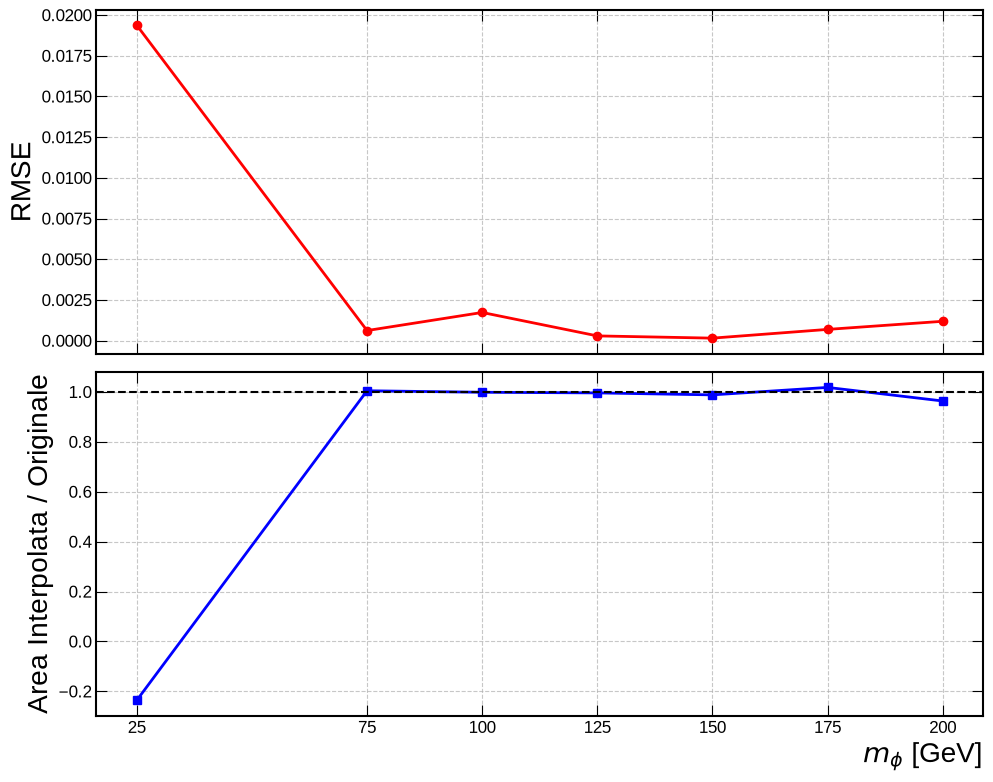

In [20]:
import numpy as np
import matplotlib.pyplot as plt

masse_testate = []
rmse_valori = []
rapporti_aree = []

x_prova = np.linspace(0, 250, 300)

for k, parametri_originali in fit_MH_values.items():
    if k.startswith("MH"):
        massa_corrente = float(k.replace("MH", ""))
        
        if massa_corrente == 50.0:
            continue
            
        masse_testate.append(massa_corrente)
        
        # 1. Modello interpolato (Leave-One-Out)
        modello_interpolato = DoubleVoigtFit3(
            mass=massa_corrente, 
            fit_values=fit_MH_values, 
            exclude_mass=[50, massa_corrente]
        )
        parametri_interpolati = modello_interpolato.get_fit_parameters()
        
        # 2. Estrazione argomenti
        param_names = modello_interpolato.param_names
        args_interpolati = [parametri_interpolati[p] for p in param_names]
        args_originali = [parametri_originali[p] for p in param_names]
        
        # 3. Generazione distribuzioni
        y_interpolati = voigt2(x_prova, *args_interpolati)
        y_originali = voigt2(x_prova, *args_originali)
        
        # 4. Calcolo RMSE (Errore sulla forma)
        rmse = np.sqrt(np.mean((y_interpolati - y_originali) ** 2))
        rmse_valori.append(rmse)
        
        # 5. Calcolo Rapporto Aree (Conservazione degli eventi/segnale)
        area_interpolata = np.sum(y_interpolati)
        area_originale = np.sum(y_originali)
        rapporto_area = area_interpolata / area_originale
        rapporti_aree.append(rapporto_area)
        
        print(f"Massa {massa_corrente:3.0f} GeV -> RMSE: {rmse:.6f} | Rapporto Aree: {rapporto_area:.4f}")

# --- GRAFICI DEI RISULTATI ---

# Ordiniamo le liste per massa crescente
masse_ordinate, rmse_ordinati, aree_ordinate = zip(*sorted(zip(masse_testate, rmse_valori, rapporti_aree)))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Pannello 1: RMSE
ax1.plot(masse_ordinate, rmse_ordinati, marker='o', color='red', linewidth=2)
ax1.set_ylabel("RMSE", fontsize=20)
#ax1.set_title("Qualità dell'Interpolazione al variare della Massa", fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.7)

# Pannello 2: Rapporto delle Aree
ax2.plot(masse_ordinate, aree_ordinate, marker='s', color='blue', linewidth=2)
ax2.axhline(1, color='black', linestyle='--')
ax2.set_xlabel("$m_{\phi}$ [GeV]", fontsize=20, loc='right')
ax2.set_ylabel("Area Interpolata / Originale", fontsize=20)
ax2.grid(True, linestyle='--', alpha=0.7)

# Mostra tutti i tick delle masse sull'asse X
ax2.set_xticks(masse_ordinate)

plt.tight_layout()
plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Grafico_RMSE_Rapporto_Aree.png', bbox_inches='tight')
plt.show()

In [21]:
#Vediamo smeplicmente lo scarto tra i parameti tra la massa interpolata e quella originale

for k, parametri_originali in fit_MH_values.items():
    if k.startswith("MH"):
        massa_corrente = float(k.replace("MH", ""))
        
        if massa_corrente == 50.0:
            continue
            
        # Modello interpolato (Leave-One-Out)
        modello_interpolato = DoubleVoigtFit3(
            mass=massa_corrente, 
            fit_values=fit_MH_values, 
            exclude_mass=[50, massa_corrente]
        )
        parametri_interpolati = modello_interpolato.get_fit_parameters()
        
        # Calcolo dello scarto tra i parametri
        scarto_parametri = {p: parametri_interpolati[p] - parametri_originali[p] for p in modello_interpolato.param_names}
        scarto_parametri=scarto_parametri.items()
        
        print(f"Massa {massa_corrente:3.0f} GeV -> Scarto Parametri: {scarto_parametri}")

Massa  25 GeV -> Scarto Parametri: dict_items([('norm', np.float64(-0.2820311999637778)), ('mu', np.float64(-7.170740141040913)), ('sigma', np.float64(10.184775387345047)), ('gamma', np.float64(2.0533801350864973)), ('norm2', np.float64(0.2730130562378194)), ('mu2', np.float64(15.767706663320471)), ('sigma2', np.float64(-14.732910048543879)), ('gamma2', np.float64(0.0))])
Massa  75 GeV -> Scarto Parametri: dict_items([('norm', np.float64(0.09401039998792593)), ('mu', np.float64(2.3902467136802983)), ('sigma', np.float64(-3.3949251291150153)), ('gamma', np.float64(-0.6844600450288323)), ('norm2', np.float64(-0.0910043520792731)), ('mu2', np.float64(-5.2559022211068225)), ('sigma2', np.float64(4.910970016181293)), ('gamma2', np.float64(0.0))])
Massa 100 GeV -> Scarto Parametri: dict_items([('norm', np.float64(-0.04254863633679651)), ('mu', np.float64(-1.7977495921555828)), ('sigma', np.float64(1.902782586105487)), ('gamma', np.float64(0.4451717388132326)), ('norm2', np.float64(0.04217616


------------------------------
 MASSA  25 GeV 
------------------------------
Scarto normalizzato per norm    : 0.1710
Scarto normalizzato per mu      : 0.0857
Scarto normalizzato per sigma   : 11.5658
Scarto normalizzato per gamma   : 98.7580
Scarto normalizzato per norm2   : 0.7871
Scarto normalizzato per mu2     : 0.3366
Scarto normalizzato per sigma2  : 75.2681
Scarto normalizzato per gamma2  : 0.0000

------------------------------
 MASSA  75 GeV 
------------------------------
Scarto normalizzato per norm    : 0.0213
Scarto normalizzato per mu      : 0.0010
Scarto normalizzato per sigma   : 0.1715
Scarto normalizzato per gamma   : 0.0570
Scarto normalizzato per norm2   : 0.0609
Scarto normalizzato per mu2     : 0.0045
Scarto normalizzato per sigma2  : 1.0241
Scarto normalizzato per gamma2  : 0.0000

------------------------------
 MASSA 100 GeV 
------------------------------
Scarto normalizzato per norm    : 0.0031
Scarto normalizzato per mu      : 0.0003
Scarto normalizzato pe

<>:76: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:76: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_53321/747635551.py:76: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.xlabel("$m_{\phi}$ [GeV]", fontsize=12, loc='right')


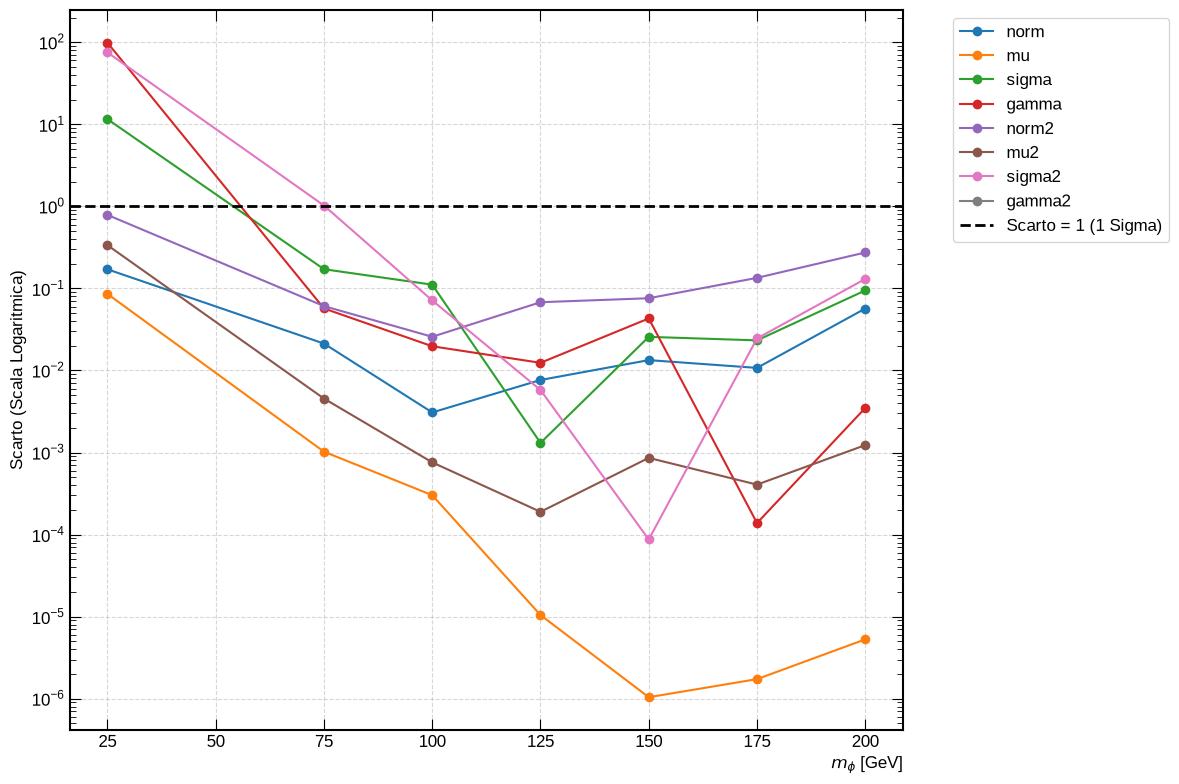

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import json

# 1. Caricamento degli errori
with open('fit_errors.json', 'r') as f:
    fit_MH_errors = json.load(f)

param_names = ["norm", "mu", "sigma", "gamma", "norm2", "mu2", "sigma2", "gamma2"]
scarti_normalizzati = {p: [] for p in param_names}
masse_testate = []

for k, parametri_originali in fit_MH_values.items():
    if k.startswith("MH"):
        massa_corrente = float(k.replace("MH", ""))
        
        if massa_corrente == 50.0:
            continue
            
        # Costruiamo la chiave esatta usata nel file json degli errori 
        chiave_massa_errori = f"{k}_errors"
        
        # Controllo di sicurezza con la nuova chiave
        if chiave_massa_errori not in fit_MH_errors:
            print(f"\n ATTENZIONE: {chiave_massa_errori} non trovato in fit_errors.json! Salto.")
            continue
            
        masse_testate.append(massa_corrente)
        
        # Interpolazione Leave-One-Out
        modello = DoubleVoigtFit3(massa_corrente, fit_MH_values, exclude_mass=[50, massa_corrente])
        parametri_interpolati = modello.get_fit_parameters()
        
        print(f"\n{'-'*30}")
        print(f" MASSA {massa_corrente:3.0f} GeV ")
        print(f"{'-'*30}")
        
        for p in param_names:
            val_vero = parametri_originali[p]
            val_interp = parametri_interpolati[p]
            
            # Estrazione dell'errore usando la chiave corretta per la massa e per il parametro
            errore_fit = fit_MH_errors[chiave_massa_errori][p] 
            
            # Evitiamo divisioni per zero se l'errore dovesse essere 0.0 nel JSON
            if errore_fit == 0:
                print(f"⚠️ Errore nullo per {p}, impossibile calcolare lo scarto.")
                continue

            # Calcolo dello scarto normalizzato
            scarto_norm = float(((val_vero - val_interp) ** 2)/val_vero**2) 
            
            scarti_normalizzati[p].append(scarto_norm)
            
            print(f"Scarto normalizzato per {p:7s} : {scarto_norm:.4f}")

# ---------------------------------------------------------
# GRAFICO DEGLI SCARTI NORMALIZZATI 
# ---------------------------------------------------------
if len(masse_testate) > 0:
    masse_ordinate = sorted(masse_testate)
    indici_ord = np.argsort(masse_testate)

    plt.figure(figsize=(12, 8))

    for p in param_names:
        # Selezioniamo solo i valori calcolati e li ordiniamo
        scarti_p_ordinati = np.array(scarti_normalizzati[p])[indici_ord]

        plt.plot(masse_ordinate, scarti_p_ordinati, marker='o', label=p, linewidth=1.5)

    plt.axhline(1.0, color='black', linestyle='--', linewidth=2, label='Scarto = 1 (1 Sigma)')

    plt.yscale('log') 
    #plt.title("Scarto Normalizzato dei Parametri in funzione della Massa", fontsize=14, pad=15)
    plt.xlabel("$m_{\phi}$ [GeV]", fontsize=12, loc='right')
    plt.ylabel("Scarto (Scala Logaritmica)", fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Grafico_Scarti_Parametri.png', bbox_inches='tight')
    plt.show()
else:
    print("Nessuna massa valida trovata per generare il grafico.")